# The Sound of Silence (Technical Notebook)

Article: [The Sound of Silence: When No Data Is the Best Data](https://open.substack.com/pub/beyondcorrelation1/p/the-sound-of-silence-when-no-data?r=1dl7er&utm_campaign=post&utm_medium=web)

This notebook is the *technical simulation + plots* (run top-to-bottom).

In [1]:
import importlib
import subprocess
import sys


def _pip_install(args: list[str]) -> None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *args])


def ensure(package: str, import_name: str | None = None):
    name = import_name or package
    try:
        importlib.import_module(name)
        return
    except Exception:
        pass

    print(f"Installing {package}...")
    try:
        _pip_install([package])
        return
    except Exception as e:
        msg = str(e)
        if "externally-managed-environment" not in msg:
            raise

    # Fallback for PEP 668 environments
    try:
        _pip_install(["--user", package])
    except Exception:
        raise RuntimeError(
            "Package installation failed due to a locked Python environment.\n"
            "Create a virtualenv and re-run the notebook:\n\n"
            "  python3 -m venv .venv\n"
            "  source .venv/bin/activate\n"
            "  pip install numpy pandas matplotlib seaborn\n"
        )


ensure("numpy")
ensure("pandas")
ensure("matplotlib")
ensure("seaborn")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.figsize": (12, 4)})

print("Environment is ready.")

Environment is ready.


## 1) Setup

Simulate hits by location + a survival mechanism. We only observe **returning** planes.

In [2]:
# Experiment settings
n_planes = 1000
locations = ["Engine", "Cockpit", "Wings", "Fuselage"]

# Enemy fire is uniform in this simulation (ground truth)
hit_location = np.random.choice(locations, size=n_planes, p=[0.25, 0.25, 0.25, 0.25])

# Survival mechanism: critical regions are much deadlier
survival_prob = {
    "Engine": 0.10,   # mostly fatal
    "Cockpit": 0.05,  # mostly fatal
    "Wings": 0.92,    # mostly survivable
    "Fuselage": 0.88  # mostly survivable
}

survived = np.array([
    np.random.rand() < survival_prob[loc]
    for loc in hit_location
], dtype=int)

df = pd.DataFrame({
    "hit_location": hit_location,
    "survived": survived
})

observed = df[df["survived"] == 1].copy()

print(f"Total planes: {len(df)}")
print(f"Returned planes (observable): {len(observed)}")
print(f"Did not return (missing from data): {len(df) - len(observed)}")

print("\nGround truth hit distribution (all planes):")
display(df["hit_location"].value_counts().reindex(locations))

print("Observed hit distribution (returning planes only):")
display(observed["hit_location"].value_counts().reindex(locations).fillna(0).astype(int))

Total planes: 1000
Returned planes (observable): 493
Did not return (missing from data): 507

Ground truth hit distribution (all planes):


hit_location
Engine      269
Cockpit     234
Wings       254
Fuselage    243
Name: count, dtype: int64

Observed hit distribution (returning planes only):


hit_location
Engine       34
Cockpit      13
Wings       230
Fuselage    216
Name: count, dtype: int64

## 2) Plot

Truth (all planes) vs observed (survivors only).

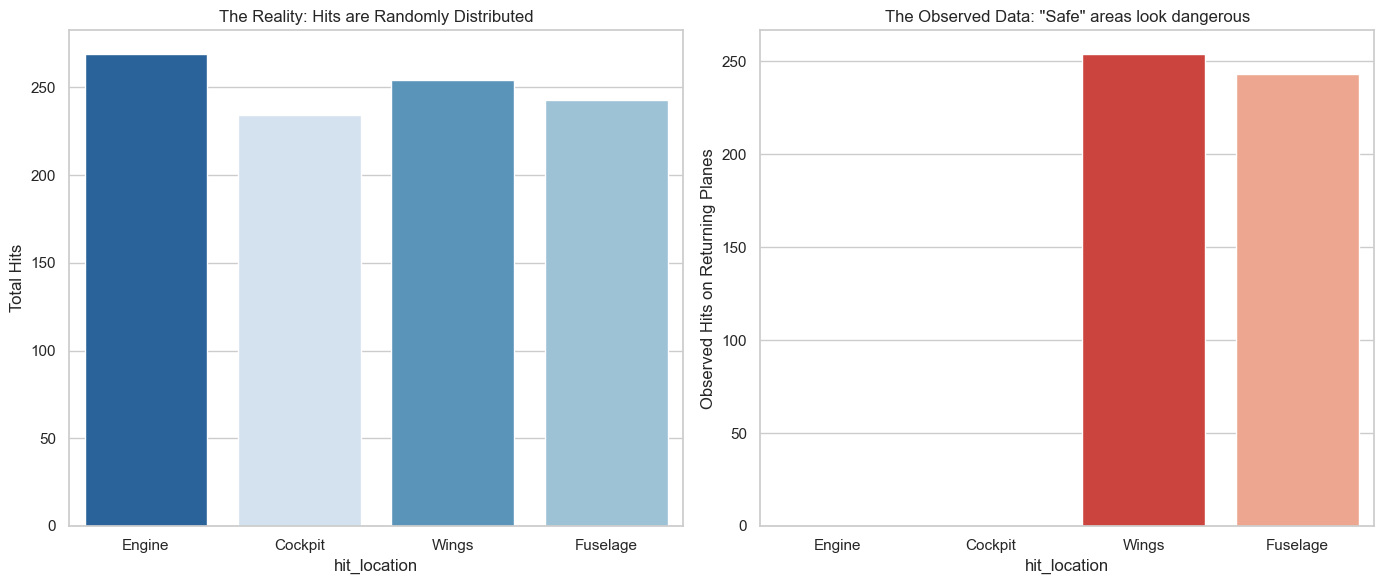

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Experiment Settings
np.random.seed(42)
n_planes = 1000
# Possible hit locations
locations = ['Engine', 'Cockpit', 'Wings', 'Fuselage']

# 1. Generate Data: Hits are random (Uniform Distribution)
# Reality: The enemy shoots everywhere.
hits = np.random.choice(locations, size=n_planes, p=[0.25, 0.25, 0.25, 0.25])
df = pd.DataFrame({'hit_location': hits})

# 2. Causal Mechanism:
# Hit in Engine/Cockpit is fatal -> Plane does not return (Survival=0)
# Hit in Wings/Fuselage is survivable -> Plane returns (Survival=1)
def simulate_survival(location):
    if location in ['Engine', 'Cockpit']:
        return 0 # Crashed
    return 1 # Returned to base
df['survived'] = df['hit_location'].apply(simulate_survival)

# 3. What the Engineers saw (Only Survivors)
observed_data = df[df['survived'] == 1]

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# Plot 1: The Reality (All planes)
sns.countplot(
    x='hit_location',
    hue='hit_location',
    data=df,
    order=locations,
    ax=axes[0],
    palette='Blues',
    legend=False,
)
axes[0].set_title('The Reality: Hits are Randomly Distributed')
axes[0].set_ylabel('Total Hits')
# Plot 2: The Observed Data (Survivorship Bias)
sns.countplot(
    x='hit_location',
    hue='hit_location',
    data=observed_data,
    order=locations,
    ax=axes[1],
    palette='Reds',
    legend=False,
)
axes[1].set_title('The Observed Data: "Safe" areas look dangerous')
axes[1].set_ylabel('Observed Hits on Returning Planes')
plt.tight_layout()
plt.show()


## 3) Takeaway

Survivor-only data over-represents survivable zones (`Wings`, `Fuselage`) and under-represents fatal zones (`Engine`, `Cockpit`).